# Description File

This file loads the cleaned speeches in csv from google drive. Currently, we sample only the first 10 speeches. For each speech, we select the first 512 tokens. Then, it uses FinBERT and i) classifies each speech as 'positive', 'neutral' or 'negative' (secondary to us) and ii) extracts the embedding for each speech from the last layer. In a next step, I take the embedding and perform a principal component analysis (PCA), focusing on the 10 most important topics. This value is of course up to debate. Finally, we merge the date of the speech and the regional bank of the Fed back to the data and save it as *'speech_embeddings_pca.csv'*.

Note that I already extract the CLS token from the last hidden layer and take the mean over all tokens in the last hidden layer.

# Set-Up
First, we set up the environment. We load all necessary packages, I also connect to my local google drive where the cleaned data is saved. Then, load the cleaned data.



In [90]:
import pandas as pd
from google.colab import drive
import numpy as np
import pickle
import subprocess

# embedding
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


In [91]:
# set up mount to google drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [92]:
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Data

In [93]:
path = "/content/drive/MyDrive/AML/cleaned_speeches.csv"
df = pd.read_csv(path)

In [94]:
print(df.columns)
print(df['CentralBank'].unique())
# so the board and the 12 regional feds

# sort by date
df = df.sort_values('parsed_date').reset_index(drop=True)

Index(['Unnamed: 0', 'URL', 'PDF', 'Title', 'Subtitle', 'Date', 'Authorname',
       'Role', 'Gender', 'CentralBank', 'Country', 'text', 'Filename',
       'Language', 'Source', 'word_count', 'parsed_date', 'text-cleaned',
       'word_count_cl', 'word_count_dirt', 'words-removed'],
      dtype='object')
['Federal Reserve Bank of Atlanta' 'Federal Reserve Bank of San Francisco'
 'Federal Reserve Bank of Chicago' 'Federal Reserve Bank of Philadelphia'
 'Federal Reserve Bank of Boston' 'Federal Reserve Bank of Dallas'
 'Board of Governors of the Federal Reserve'
 'Federal Reserve Bank of St Louis' 'Federal Reserve Bank of Cleveland'
 'Federal Reserve Bank of Kansas City'
 'Federal Reserve Bank of Minneapolis' 'Federal Reserve Bank of New York'
 'Federal Reserve Bank of Richmond']


# Running the Model

In [95]:
# just take first ten speeches for now to get the whole thing up and running
df_sample = df.head(10)

# tokenize
inputs = tokenizer(
    list(df_sample['text-cleaned']),
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=512
)

In [96]:
# some very basic inference
# this is not really relevant for our task but still want to look at it :)

with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
labels = ["positive", "negative", "neutral"]

for i, pred in enumerate(predictions):
    sentiment = labels[pred.argmax()]
    score = pred.max().item()
    print(f"Speech {i+1}: {sentiment} ({score:.2f})")

Speech 1: neutral (0.62)
Speech 2: neutral (0.84)
Speech 3: neutral (0.47)
Speech 4: neutral (0.89)
Speech 5: neutral (0.92)
Speech 6: neutral (0.90)
Speech 7: neutral (0.63)
Speech 8: neutral (0.60)
Speech 9: neutral (0.56)
Speech 10: neutral (0.84)


In [97]:
# extract final layer
# CLS token from last hidden layer as baseline
cls_embeddings = outputs.hidden_states[-1][:, 0, :]  # shape: (10, 768)

# mean of all tokens in last hidden layer
mean_embeddings = outputs.hidden_states[-1].mean(dim=1)  # shape: (10, 768)

# Dimensionality Reduction


## CLS Embeddings

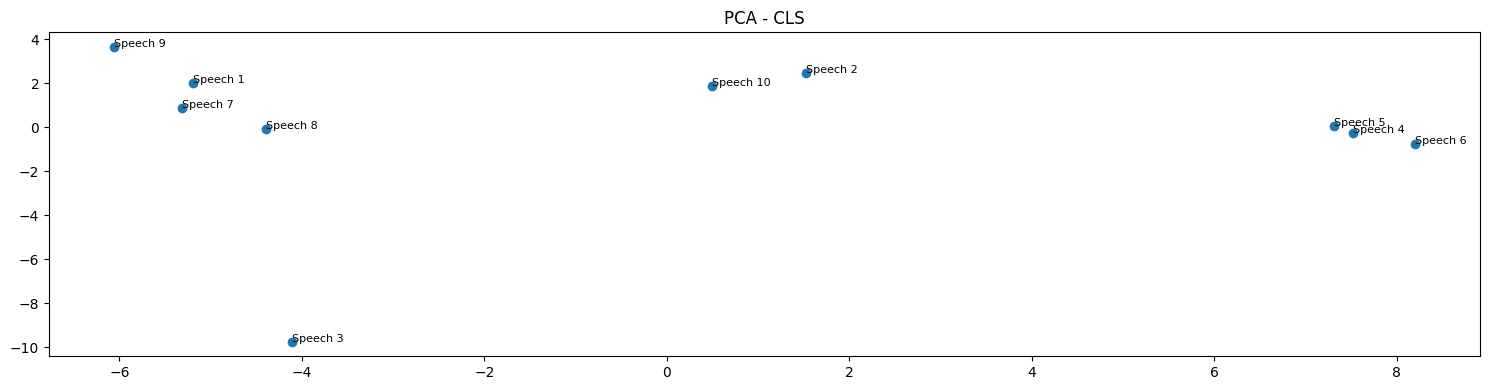

In [98]:
# get into numpy, shape (10, 768)
embeddings = cls_embeddings.numpy()

# get principal components
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(embeddings)

# --- Plot all three ---
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
ax.scatter(reduced_pca[:, 0], reduced_pca[:, 1])
for i in range(len(reduced_pca)):
  ax.annotate(f"Speech {i+1}", (reduced_pca[i, 0], reduced_pca[i, 1]), fontsize=8)
  ax.set_title("PCA - CLS")
plt.tight_layout()
plt.show()

Note: the closer the embedding of two speeches are, the more similar their principal components.

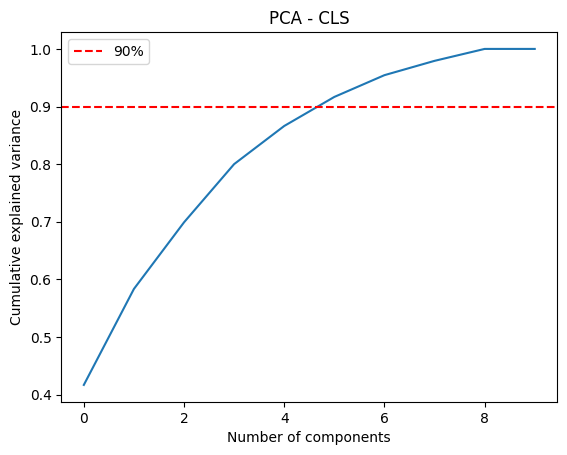

In [99]:
# now more elaborate with 10 components
pca_cls = PCA(n_components=10)
reduced_pca_cls = pca_cls.fit_transform(embeddings)

plt.plot(np.cumsum(pca_cls.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(0.90, color='r', linestyle='--', label='90%')
plt.title("PCA - CLS")
plt.legend()
plt.show()
# take the number of topics were around 90% of all variance is explained
# also, i think if we first fine-tune the model, we will need fewer components
# because it will already be a much better fit on our data

## Mean Embeddings

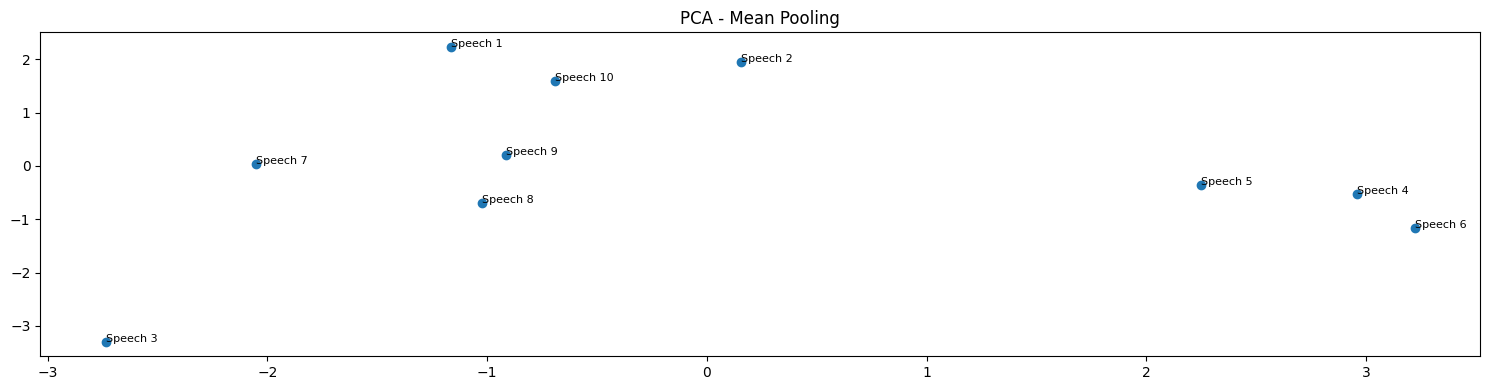

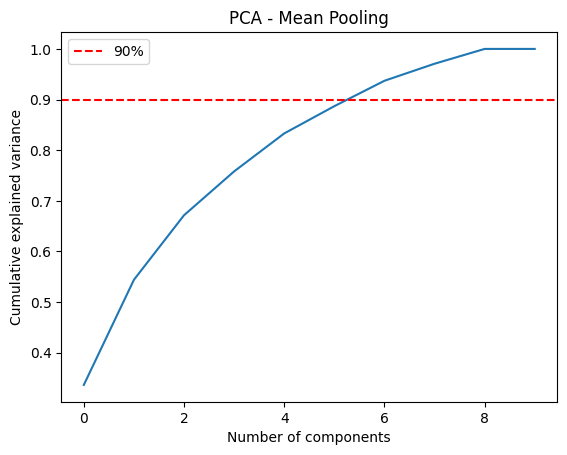

In [100]:
# get into numpy, shape (10, 768)
embeddings = mean_embeddings.numpy()

# get principal components with n = 2 for visualization
pca = PCA(n_components=2)
reduced_pca = pca.fit_transform(embeddings)

# simple plot of all speeches
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
ax.scatter(reduced_pca[:, 0], reduced_pca[:, 1])
for i in range(len(reduced_pca)):
  ax.annotate(f"Speech {i+1}", (reduced_pca[i, 0], reduced_pca[i, 1]), fontsize=8)
  ax.set_title("PCA - Mean Pooling")
plt.tight_layout()
plt.show()

# now more elaborate with 10 components
pca_mean = PCA(n_components=10)
reduced_pca_mean = pca_mean.fit_transform(embeddings)

plt.plot(np.cumsum(pca_mean.explained_variance_ratio_))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.axhline(0.90, color='r', linestyle='--', label='90%')
plt.title("PCA - Mean Pooling")
plt.legend()
plt.show()

# Saving Results

In [101]:
# save and get output
with open('pca_model_cls.pkl', 'wb') as f:
    pickle.dump(pca_cls, f)

# save embeddings with timestamps for the tft
pca_cls_df = pd.DataFrame(
    reduced_pca_cls,
    columns=[f'pca_cls_{i}' for i in range(reduced_pca_cls.shape[1])]
)

# add date and fed
# and save date as datetime
pca_cls_df['date'] = pd.to_datetime(df_sample['parsed_date']).dt.strftime('%Y-%m-%d').values
pca_cls_df['fed'] = df_sample['CentralBank'].values

pca_cls_df.to_csv('/content/drive/MyDrive/AML/speech_embeddings_pca_cls.csv', index=False)

print(pca_cls_df.head())
print(pca_cls_df.shape)

   pca_cls_0  pca_cls_1  pca_cls_2  pca_cls_3  pca_cls_4  pca_cls_5  \
0  -5.190705   2.020559  -0.643938  -3.803605   1.409046   1.396118   
1   1.531351   2.460187  -2.534304  -2.331315  -0.512377   3.674888   
2  -4.108216  -9.740594  -0.969352  -0.184771   1.440189   0.339278   
3   7.518987  -0.254877  -0.949202   0.328182  -1.697671   0.086276   
4   7.309739   0.037075   0.608645   1.094163   1.960324   0.158403   

   pca_cls_6  pca_cls_7  pca_cls_8     pca_cls_9        date  \
0   1.424754  -2.490870   1.082731 -9.388705e-07  1987-04-01   
1  -1.001234   2.304222  -0.164366 -9.388705e-07  1989-04-01   
2   0.069940   0.495563  -0.234135 -9.388705e-07  1993-04-01   
3   2.662215  -0.843432  -2.319430 -9.388700e-07  1993-04-01   
4  -3.588361  -1.693607  -0.368069 -9.388701e-07  2004-04-01   

                                     fed  
0       Federal Reserve Bank of St Louis  
1      Federal Reserve Bank of Cleveland  
2  Federal Reserve Bank of San Francisco  
3        Federal

In [102]:
# save and get output
with open('pca_model_mean.pkl', 'wb') as f:
    pickle.dump(pca_mean, f)

# save embeddings with timestamps for the tft
pca_mean_df = pd.DataFrame(
    reduced_pca_mean,
    columns=[f'pca_mean_{i}' for i in range(reduced_pca_mean.shape[1])]
)

# add date and fed
# and save date as datetime
pca_mean_df['date'] = pd.to_datetime(df_sample['parsed_date']).dt.strftime('%Y-%m-%d').values
pca_mean_df['fed'] = df_sample['CentralBank'].values

pca_mean_df.to_csv('/content/drive/MyDrive/AML/speech_embeddings_pca_cls.csv', index=False)

print(pca_mean_df.head())
print(pca_mean_df.shape)

   pca_mean_0  pca_mean_1  pca_mean_2  pca_mean_3  pca_mean_4  pca_mean_5  \
0   -1.165044    2.231012   -0.775852    0.606645    0.085431   -0.883173   
1    0.156782    1.955812   -1.076950   -0.994081    1.928944    0.356706   
2   -2.736175   -3.292897   -1.711250    0.407949    0.442436   -0.221908   
3    2.957836   -0.526267   -0.457420   -1.011509   -0.835985   -0.743220   
4    2.246878   -0.352598    0.234342    1.538448    0.322802    1.653286   

   pca_mean_6  pca_mean_7  pca_mean_8    pca_mean_9        date  \
0    0.303245    0.401483    1.182739 -6.214150e-07  1987-04-01   
1   -0.012258   -0.230366   -0.627205 -6.214150e-07  1989-04-01   
2   -0.277327    0.203007   -0.100235 -6.214152e-07  1993-04-01   
3    0.599925    1.023907   -0.461479 -6.214155e-07  1993-04-01   
4    0.093740    0.518243    0.258464 -6.214150e-07  2004-04-01   

                                     fed  
0       Federal Reserve Bank of St Louis  
1      Federal Reserve Bank of Cleveland  
2  Fe

In [120]:
# change directory
import json

with open('/content/drive/MyDrive/AML/AML_Embeddings_1.ipynb', 'r') as f:
    nb = json.load(f)

# remove problematic widget metadata
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open('/content/drive/MyDrive/AML/AML_Embeddings_1_clean.ipynb', 'w') as f:
    json.dump(nb, f)

import os
os.chdir('/content/aml2026-group-3')

def run_git_cmd(cmd):
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as e:
        print(f"Error executing {' '.join(cmd)}: {e.stderr}")

# create and switch to new branch
run_git_cmd(['git', 'checkout', '-B', 'embeddings-pipeline'])
os.makedirs('src', exist_ok=True)

# copy notebook, commit, push
subprocess.run(['cp', '/content/drive/MyDrive/AML/AML_Embeddings_1_clean.ipynb', 'src/embeddings_pipeline.ipynb'])
run_git_cmd(['git', 'add', 'src/embeddings_pipeline.ipynb'])
run_git_cmd(['git', 'commit', '-m', 'Add FinBERT embedding and PCA pipeline'])
run_git_cmd(['git', 'push', 'origin', 'embeddings-pipeline'])